## Package and Data Imports

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

from train_utils import get_smiles, get_abrahams, train_looc, split_scores

data_path = Path(os.getcwd()) / 'data' / 'sorption_data.csv'
data = pd.read_csv(data_path, sep=';', header=0, decimal=',')

## Preprocessing
  * Replace compound names with Abrahams parameters

  * Split data in dependent (y) and independent variables (X)

  * Lower bound the Cb dosage targets at $10^{-15}$

  * Scale Cb dosages with log($\cdot$) as dependent variable

In [2]:
abrahams_cols = ['E','S','A','B','V','L']
data[abrahams_cols] = data['Compound'].apply(
    lambda c: get_abrahams(
        get_smiles(c),
        data_path.parent / 'SoluteParamResults.csv'
    )
)

for tar in ('Cb dosage 0.1 µg/L', 'Cb dosage 1 µg/L'):
    data.loc[data[tar] < 10e-15, tar] = 10e-15

data['log Cb dosage 0.1 µg/L'] = np.log10(data['Cb dosage 0.1 µg/L'])
data['log Cb dosage 1 µg/L'] = np.log10(data['Cb dosage 1 µg/L'])

target_cols = ['log Cb dosage 1 µg/L', 'log Cb dosage 0.1 µg/L']
soil_cols = [
    'Corg [% C]', 'CEC [meq/100g]', 'F quartz',
    'F non ex clay', 'F ex clay', 'Feldspar', 'Silicate', 'BET'
]
sorbat_cols = ['logKow', 'pka', 'logDow']

X = data.loc[:, soil_cols + sorbat_cols + ['pH'] + abrahams_cols]
X_whc = data.loc[:, soil_cols + sorbat_cols + ['pH'] + abrahams_cols + ['WHC']]
X_min = data.loc[:, sorbat_cols + ['pH']]
X_min_whc = data.loc[:, sorbat_cols + ['pH', 'WHC']]

## Training of various models

4 different model classes [Kernel Ridge Regression](https://scikit-learn.org/stable/modules/kernel_ridge.html) (KRR), [Partial Least Squares Regression](https://en.wikipedia.org/wiki/Partial_least_squares_regression) (PLS), [Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#random-forests) (RF) and [Gradient Boosted Trees](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosted-trees) (GB) are used to train models for the  log Cb dosage targets.

Besides models on all data, minimal baseline models (using logKow and pka as proxy for sorbate, pH as proxy for soil and logDow as proxy for sorbat-soil interactions) and models including water holding capacity are trained.

The models are internally validated with  [Cross-Validation](https://scikit-learn.org/stable/modules/cross_validation.html), more concrete with [Leave-One-Out-Cross-Validation](https://scikit-learn.org/stable/modules/cross_validation.html#leave-one-out-loo).
For any datapoint $x_0$, a  model is trained on the remaining data and evaluated on the (unseen) datum $x_0$. This gives a rough estimate of the models performance on unseen data (generalization).

In [3]:
import itertools

from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from train_utils import KRR_GRID, PLS_GRID, RF_GRID, GB_GRID

save_dir = Path(os.getcwd()) / 'models'

score_dict = {
    (name, target): train_looc(
        model, grid, target, save_dir, X, data[target]
    )
    for (model, name, grid), target in itertools.product(
        [
            (PLSRegression(), 'PLS', PLS_GRID), (KernelRidge(), 'KRR', KRR_GRID),
            (RandomForestRegressor(), 'RF', RF_GRID), (GradientBoostingRegressor(), 'GB', GB_GRID)
        ],
        target_cols
    )
}
score_dict_whc = {
    (name, target): train_looc(
        model, grid, target, save_dir / 'whc', X_whc, data[target]
    )
    for (model, name, grid), target in itertools.product(
        [
            (PLSRegression(), 'PLS', PLS_GRID), (KernelRidge(), 'KRR', KRR_GRID),
            (RandomForestRegressor(), 'RF', RF_GRID), (GradientBoostingRegressor(), 'GB', GB_GRID)
        ],
        target_cols
    )
}
# PLS grid needs adaption, as max number of components is bound by size of X
score_dict_min = {
    (name, target): train_looc(
        model, grid, target, save_dir / 'min', X_min, data[target]
    )
    for (model, name, grid), target in itertools.product(
        [
            (PLSRegression(), 'PLS', PLS_GRID | {'regressor__n_components': [2,3,4]}),
            (KernelRidge(), 'KRR', KRR_GRID), (RandomForestRegressor(), 'RF', RF_GRID),
            (GradientBoostingRegressor(), 'GB', GB_GRID)
        ],
        target_cols
    )
}
score_dict_min_whc = {
    (name, target): train_looc(
        model, grid, target, save_dir / 'min' / 'whc', X_min_whc, data[target]
    )
    for (model, name, grid), target in itertools.product(
        [
            (PLSRegression(), 'PLS', PLS_GRID | {'regressor__n_components': [2,3,4,5]}),
            (KernelRidge(), 'KRR', KRR_GRID), (RandomForestRegressor(), 'RF', RF_GRID),
            (GradientBoostingRegressor(), 'GB', GB_GRID)
        ],
        target_cols
    )
}

Predicting the targets is possible with some outliers, with regard to the root mean squared error (RMSE). There is not much visible difference between models and the different sets of independent variables, as demonstrated by box-and-whisker plots of the RMSE errors of the LOOCV (cf. Figure S5 in the Supplementary Information):

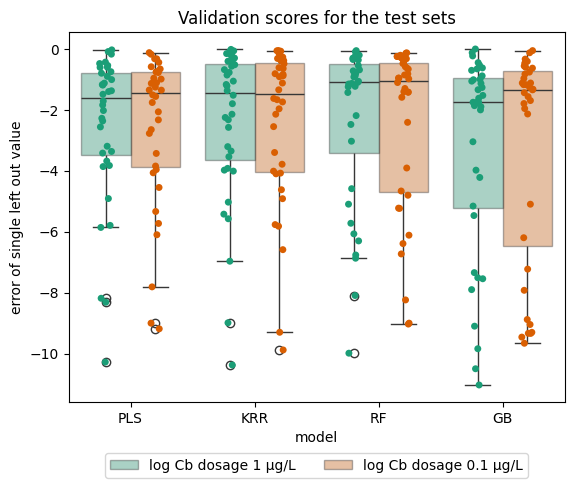

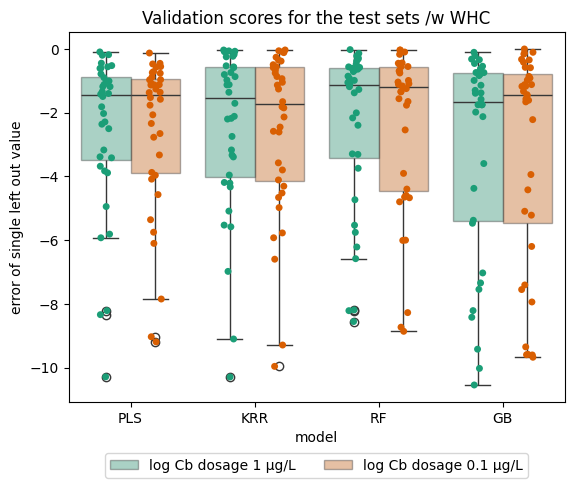

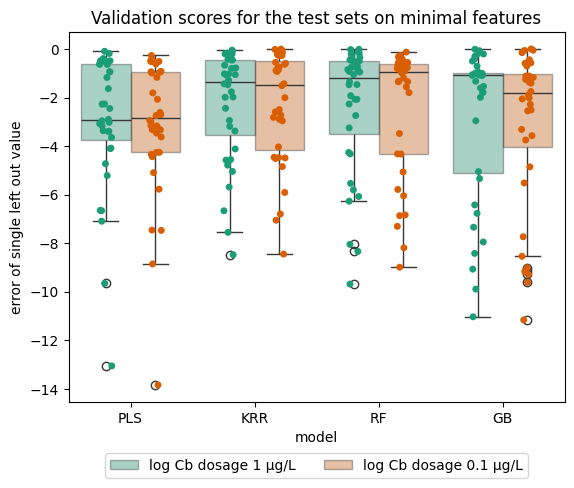

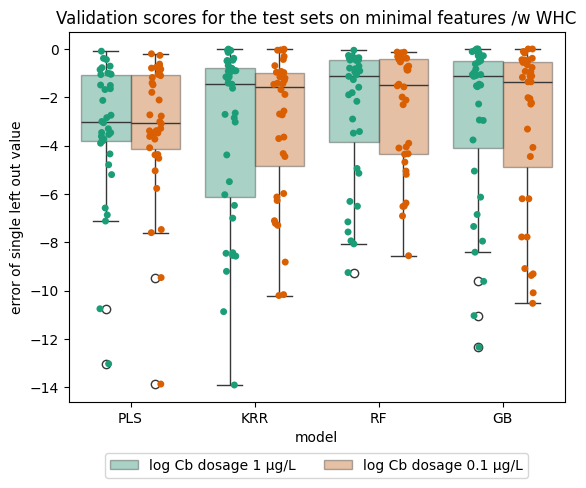

In [4]:
for (scores, spec) in [
    (score_dict, ''), (score_dict_whc, ' /w WHC'),
    (score_dict_min, ' on minimal features'),
    (score_dict_min_whc, ' on minimal features /w WHC')
]:
    sns.set_palette(plt.cm.Dark2.colors)
    sns.boxplot(
        data=split_scores(scores).explode(column='test_score').reset_index(),
        x='model', y='test_score', hue='target',
        boxprops={'alpha': 0.4}, showmeans=False
    )
    sns.stripplot(
        data=split_scores(scores).explode(column='test_score').reset_index(),
        x='model', y='test_score', hue='target', dodge=True, legend=False
    )
    plt.legend(loc='lower center', ncols=4, bbox_to_anchor=(0.5, -0.225),)
    plt.ylabel('error of single left out value')
    plt.title(f'Validation scores for the test sets{spec}')
    plt.show()

Predicting Cb dosage using WHC has no clear effect, with only making errors bigger when adding WHC to the minimal models.
A (two-sided) wilcoxon signed rank test indicates significant worsening in case of PLS and KRR for both targets and GB for log Cb dosage 1 µg/L.

A similar comparison of the minimal model with the full dataset shows no significant differences (data also presented in Table S6 in the Supplementary Information).

In [5]:
wilcoxon_stats = split_scores(score_dict).reset_index(drop=True)
scores_whc = split_scores(score_dict_whc).reset_index(drop=True)
wilcoxon_stats['test_score_whc'] = wilcoxon_stats.apply(
    lambda df: scores_whc.loc[(scores_whc['target'] == df['target']) & (scores_whc['model'] == df['model']), 'test_score'].iloc[0],
    axis=1
)
wilcoxon_stats['result'] = wilcoxon_stats.apply(lambda x: stats.wilcoxon(x['test_score'], x['test_score_whc']), axis=1)
print('Wilcoxon signed rank tests for normal vs whc:')
print(wilcoxon_stats.loc[:,['target', 'model', 'result']],'\n')

wilcoxon_stats_min = split_scores(score_dict_min).reset_index(drop=True)
scores_min_whc = split_scores(score_dict_min_whc).reset_index(drop=True)
wilcoxon_stats_min['test_score_whc'] = wilcoxon_stats_min.apply(
    lambda df: scores_min_whc.loc[(scores_min_whc['target'] == df['target']) & (scores_min_whc['model'] == df['model']), 'test_score'].iloc[0],
    axis=1
)
wilcoxon_stats_min['result'] = wilcoxon_stats_min.apply(lambda x: stats.wilcoxon(x['test_score'], x['test_score_whc']), axis=1)
print('Wilcoxon signed rank tests for minimal vs minimal w/ whc:')
print(wilcoxon_stats_min.loc[:,['target', 'model', 'result']], '\n')

wilcoxon_stats = split_scores(score_dict).reset_index(drop=True)
scores_min = split_scores(score_dict_min).reset_index(drop=True)
wilcoxon_stats['test_score_min'] = wilcoxon_stats.apply(
    lambda df: scores_min.loc[(scores_min['target'] == df['target']) & (scores_min['model'] == df['model']), 'test_score'].iloc[0],
    axis=1
)
wilcoxon_stats['result'] = wilcoxon_stats.apply(lambda x: stats.wilcoxon(x['test_score'], x['test_score_min']), axis=1)
print('Wilcoxon signed rank tests for normal vs minimal:')
print(wilcoxon_stats.loc[:,['target', 'model', 'result']])


Wilcoxon signed rank tests for normal vs whc:
                   target model                         result
0    log Cb dosage 1 µg/L   PLS    (216.0, 0.0667966004111804)
1  log Cb dosage 0.1 µg/L   PLS  (177.0, 0.013287985610077158)
2    log Cb dosage 1 µg/L   KRR   (263.0, 0.27855437609832734)
3  log Cb dosage 0.1 µg/L   KRR   (212.0, 0.05770623646094464)
4    log Cb dosage 1 µg/L    RF    (289.0, 0.4989104079431854)
5  log Cb dosage 0.1 µg/L    RF    (303.0, 0.6468730494088959)
6    log Cb dosage 1 µg/L    GB    (253.0, 0.6231681011032775)
7  log Cb dosage 0.1 µg/L    GB   (272.5, 0.48635039568905625) 

Wilcoxon signed rank tests for minimal vs minimal w/ whc:
                   target model                           result
0    log Cb dosage 1 µg/L   PLS  (113.0, 0.00031152513111010194)
1  log Cb dosage 0.1 µg/L   PLS    (121.0, 0.000546065391972661)
2    log Cb dosage 1 µg/L   KRR    (156.0, 0.004597575025400147)
3  log Cb dosage 0.1 µg/L   KRR       (183.0, 0.017530999641167)
4 

Another visualization of the model predictions is achieved by plotting predicted vs actual values (also presented in Figure S6 in the Supplementary Information, and Figure 2 in the main text).

For this, we can distinguish two approaches, answering different questions.
Analogously to the aforementioned approach, we can train a model for each datum $x_0$ on all other data, make a predicion for $x_0$, compare it with the actual target value and repeat for all rows - resulting in 36 different models. This gives a judgement for new/unseen data, hence quantifies/visualizes generalization to some degree.

We can also train a single model on all data and compare the predictions from that model with each actual value. This gives rise to some degree of overfitting, as we evaluate on the training data. This does however tell us some things about the interdependences, learned on the given data set.

For the former, cross-validated, predictions, we can reuse the models trained above. The latter approach requires a retraining on all data, for which we need a set of best-performing hyper-parameters. Those were extracted by hand and collected in the following dictionary.

In [7]:
best_param_dict = {
    'normal' : {
        'log Cb dosage 1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'rbf', 'alpha': 1.e-03, 'gamma': 0.001},
            'RF': {'n_estimators': 50, 'criterion': 'absolute_error', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': None}
        },
        'log Cb dosage 0.1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'rbf', 'alpha': 1.e-03, 'gamma': 0.001},
            'RF': {'n_estimators': 50, 'criterion': 'absolute_error', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': None}
        }
    },
    'whc' : {
        'log Cb dosage 1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'rbf', 'alpha': 1.e-03, 'gamma': 0.001},
            'RF': {'n_estimators': 50, 'criterion': 'absolute_error', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.01 , 'max_depth': None}
        },
        'log Cb dosage 0.1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'rbf', 'alpha': 1.e-03, 'gamma': 0.001},
            'RF': {'n_estimators': 50, 'criterion': 'absolute_error', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': None}
        }
    },
    'min' : {
        'log Cb dosage 1 µg/L': {
            'PLS': {'n_components': 4},
            'KRR': {'kernel': 'polynomial', 'alpha': 1.e-02, 'degree': 2},
            'RF': {'n_estimators': 50, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': 5}
        },
        'log Cb dosage 0.1 µg/L': {
            'PLS': {'n_components': 4},
            'KRR': {'kernel': 'polynomial', 'alpha': 1.e-02, 'degree': 2},
            'RF': {'n_estimators': 50, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': 5}
        }
    },
    'min_whc' : {
        'log Cb dosage 1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'rbf', 'alpha': 1.e-05, 'gamma': 1},
            'RF': {'n_estimators': 50, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': 5}
        },
        'log Cb dosage 0.1 µg/L': {
            'PLS': {'n_components': 3},
            'KRR': {'kernel': 'polynomial', 'alpha': 10, 'degree': 3},
            'RF': {'n_estimators': 50, 'criterion': 'friedman_mse', 'min_samples_split': 2, 'min_samples_leaf': 4},
            'GB': {'loss': 'huber', 'n_estimators': 100, 'learning_rate': 0.1 , 'max_depth': 5}
        }
    }
}

PLS and RF show some skewness with respect to the diagonal (signifying perfect prediction). This is normally a bad sign, as we hope for a symmetric distribution of the errors. Here, this merely hints at the low reliability of the models in the low Cb dosage regime.

We can roughly concur, that the models work quite well down to a Cb dosage of $10^{-8}$.

R2 for log Cb dosage 1 µg/L: 0.15986501803659947
RMSE for log Cb dosage 1 µg/L: 3.8015907859263742
R2 for log Cb dosage 0.1 µg/L: 0.1872874181656775
RMSE for log Cb dosage 0.1 µg/L: 3.794561098444787


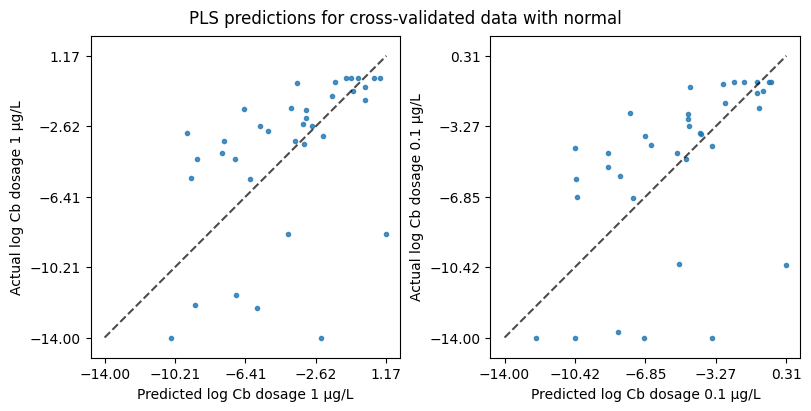

R2 for log Cb dosage 1 µg/L: 0.5730398426157467
RMSE for log Cb dosage 1 µg/L: 2.7100949507573575
R2 for log Cb dosage 0.1 µg/L: 0.5839759536363445
RMSE for log Cb dosage 0.1 µg/L: 2.714890234179573


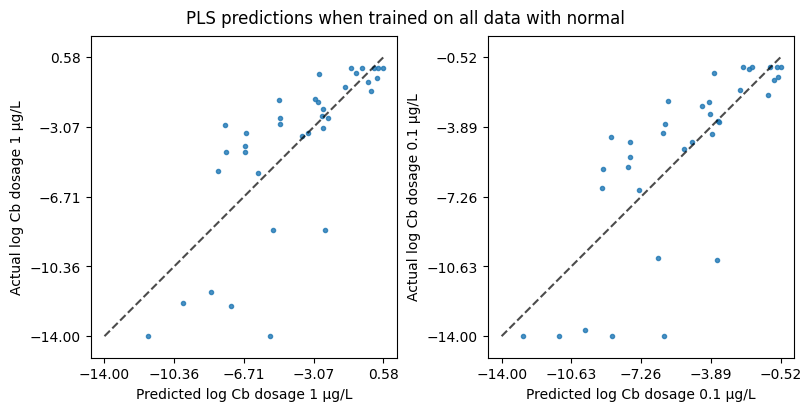

R2 for log Cb dosage 1 µg/L: 0.05767435886707717
RMSE for log Cb dosage 1 µg/L: 4.02616284271675
R2 for log Cb dosage 0.1 µg/L: 0.055445652254214495
RMSE for log Cb dosage 0.1 µg/L: 4.090783863180034


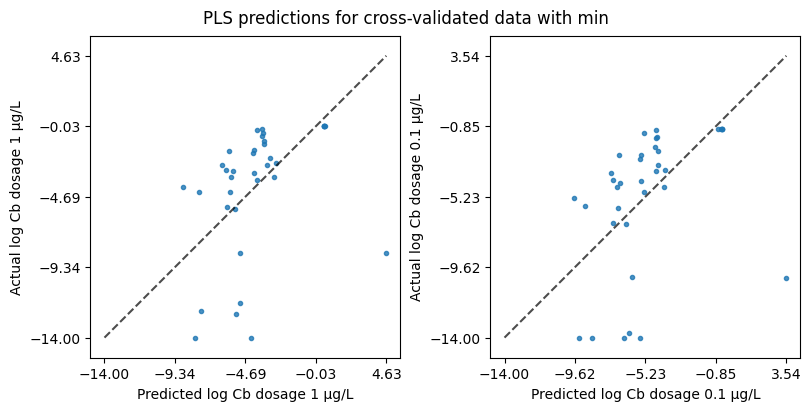

R2 for log Cb dosage 1 µg/L: 0.3671210823143133
RMSE for log Cb dosage 1 µg/L: 3.2995228972258652
R2 for log Cb dosage 0.1 µg/L: 0.3628224110107692
RMSE for log Cb dosage 0.1 µg/L: 3.35987642546671


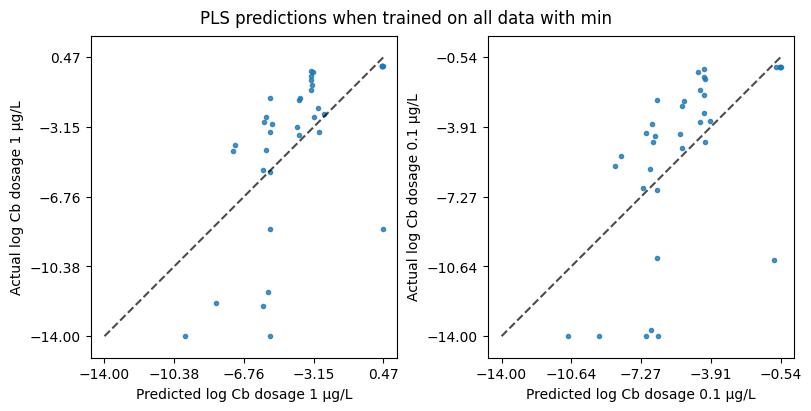

R2 for log Cb dosage 1 µg/L: 0.34770359367027304
RMSE for log Cb dosage 1 µg/L: 3.349757167565201
R2 for log Cb dosage 0.1 µg/L: 0.35284039577464477
RMSE for log Cb dosage 0.1 µg/L: 3.386092039751992


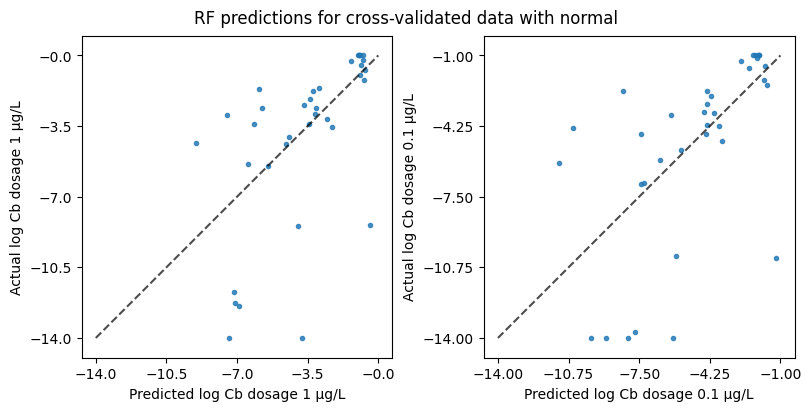

R2 for log Cb dosage 1 µg/L: 0.5673150589698094
RMSE for log Cb dosage 1 µg/L: 2.728203252577657
R2 for log Cb dosage 0.1 µg/L: 0.5903140497090286
RMSE for log Cb dosage 0.1 µg/L: 2.694130284049256


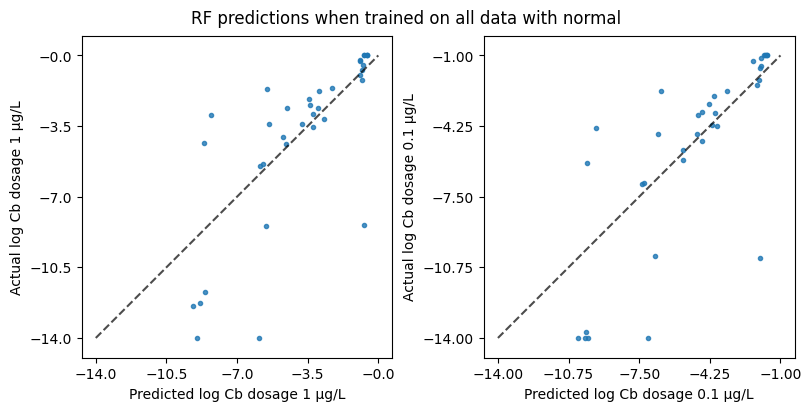

R2 for log Cb dosage 1 µg/L: 0.39789893585759173
RMSE for log Cb dosage 1 µg/L: 3.2182926211957903
R2 for log Cb dosage 0.1 µg/L: 0.40984159782793006
RMSE for log Cb dosage 0.1 µg/L: 3.2335334334356682


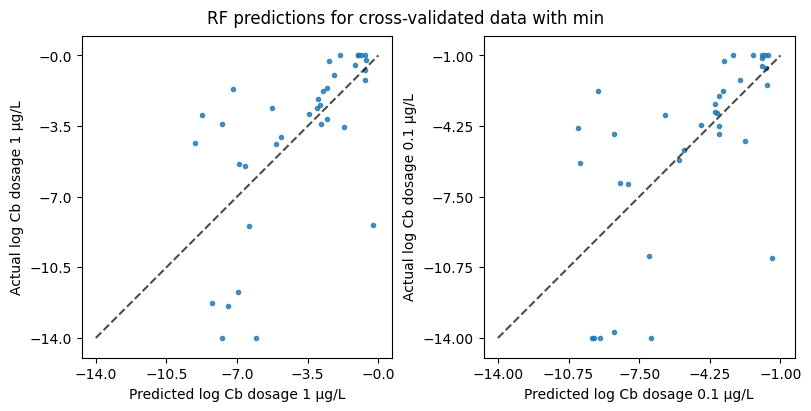

R2 for log Cb dosage 1 µg/L: 0.6006132583017694
RMSE for log Cb dosage 1 µg/L: 2.6211245246684807
R2 for log Cb dosage 0.1 µg/L: 0.6291499267651319
RMSE for log Cb dosage 0.1 µg/L: 2.563257536623542


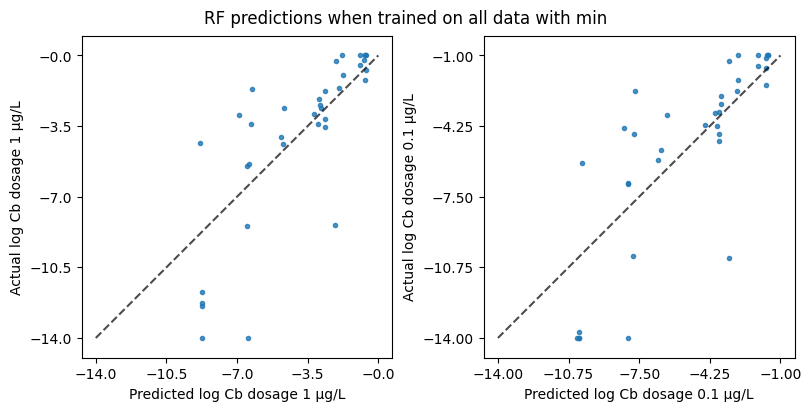

In [10]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import PredictionErrorDisplay, r2_score, root_mean_squared_error

for name, model in (('PLS', PLSRegression), ('RF', RandomForestRegressor)):
    for setting, ind in (('normal', X), ('min', X_min)):
        fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout='constrained')
        for tar, ax in zip(['log Cb dosage 1 µg/L', 'log Cb dosage 0.1 µg/L'], axs):
            y_pred = cross_val_predict(model(**best_param_dict[setting][tar][name]), ind, data[tar], cv=LeaveOneOut())
            print(f"R2 for {tar}: {r2_score(data[tar], y_pred)}")
            print(f"RMSE for {tar}: {root_mean_squared_error(data[tar], y_pred)}")
            PredictionErrorDisplay.from_predictions(data[tar], y_pred, kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker': '.'})
            ax.set(xlabel=f'Predicted {tar}', ylabel=f'Actual {tar}')
        fig.suptitle(name + ' predictions for cross-validated data with ' + setting)
        plt.savefig(Path(os.getcwd()) / 'plots' / f'{name}_{setting}_cross-validated_actual_vs_predicted.png', dpi=1500)
        plt.show()

        fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout='constrained')
        for tar, ax in zip(target_cols, axs):
            estimator = model(**best_param_dict[setting][tar][name]).fit(ind, data[tar])
            print(f"R2 for {tar}: {r2_score(data[tar], estimator.predict(ind))}")
            print(f"RMSE for {tar}: {root_mean_squared_error(data[tar], estimator.predict(ind))}")
            PredictionErrorDisplay.from_estimator(estimator, ind, data[tar], kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker': '.'})
            ax.set(xlabel=f'Predicted {tar}', ylabel=f'Actual {tar}')
        fig.suptitle(name + ' predictions when trained on all data with ' + setting)
        plt.savefig(Path(os.getcwd()) / 'plots' / f'{name}_{setting}_all-data_actual_vs_predicted.png', dpi=1500)
        plt.show()

KRR and GB models show heavy signs of overfitting. With KRR this is more subtle, but the "uniform" distribution in the cross-validated plots (for all data) indicates severe overfitting when trained on all data. With the GB models, we clearly see, that the models only memorize the data, hence this model class is totally unsuitable for our case.

R2 for log Cb dosage 1 µg/L: -0.7468560352873419
RMSE for log Cb dosage 1 µg/L: 5.481752072376893
R2 for log Cb dosage 0.1 µg/L: -0.6748864825244456
RMSE for log Cb dosage 0.1 µg/L: 5.447355857380697


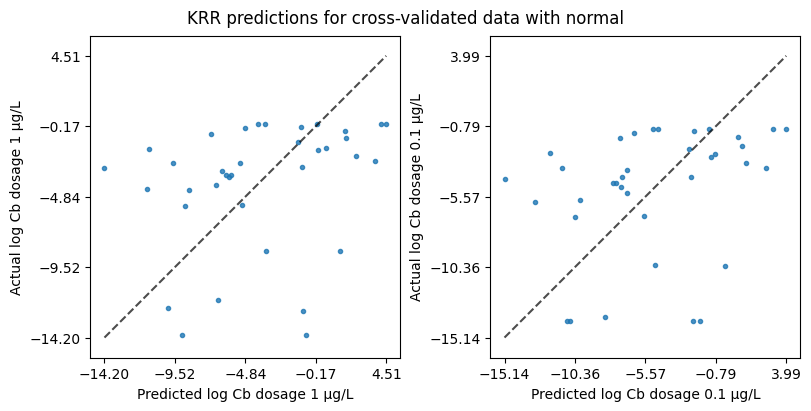

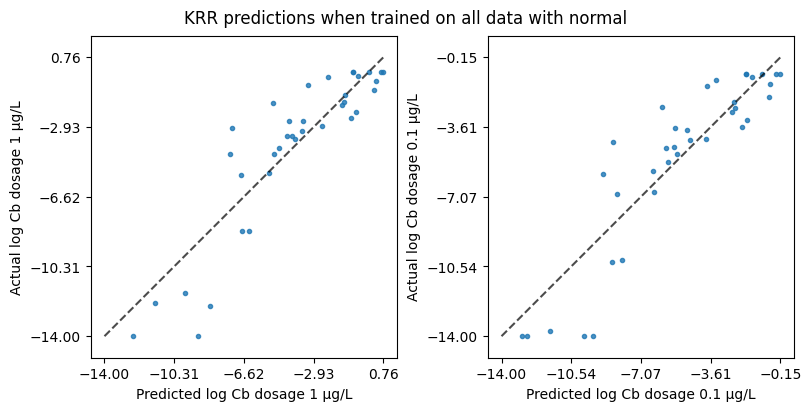

R2 for log Cb dosage 1 µg/L: 0.4681785489810576
RMSE for log Cb dosage 1 µg/L: 3.024640460690402
R2 for log Cb dosage 0.1 µg/L: 0.43220748459626157
RMSE for log Cb dosage 0.1 µg/L: 3.171669238941061


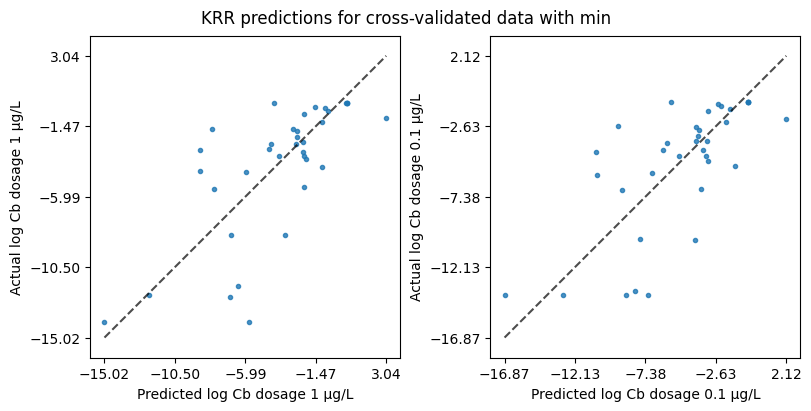

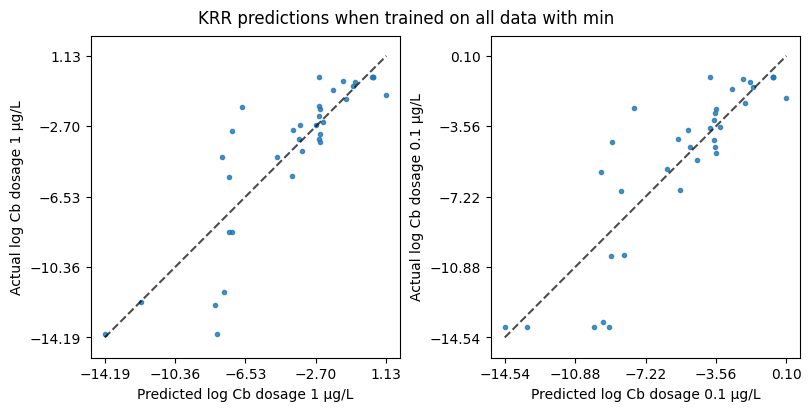

R2 for log Cb dosage 1 µg/L: -0.17968970332882694
RMSE for log Cb dosage 1 µg/L: 4.504791828199713
R2 for log Cb dosage 0.1 µg/L: -0.1799196935130256
RMSE for log Cb dosage 0.1 µg/L: 4.572137507075275


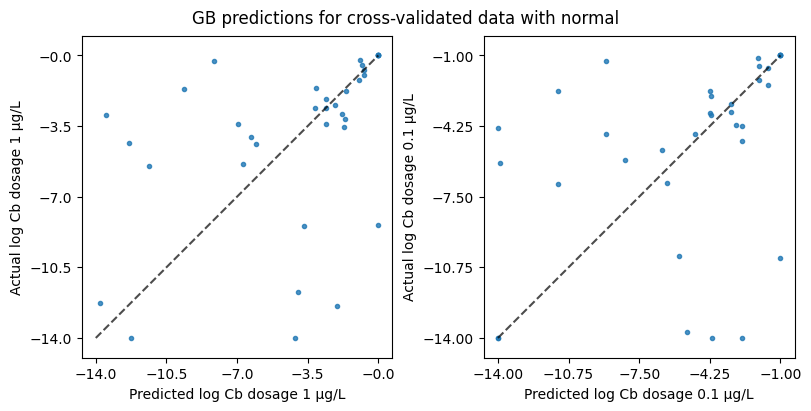

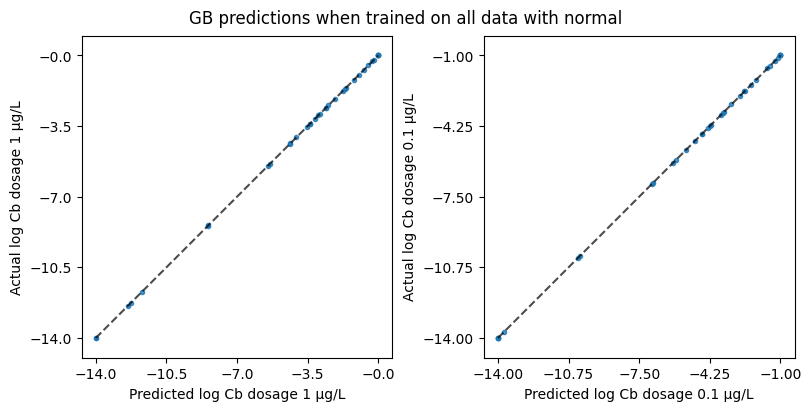

R2 for log Cb dosage 1 µg/L: -0.15867966202577444
RMSE for log Cb dosage 1 µg/L: 4.464496883256126
R2 for log Cb dosage 0.1 µg/L: -0.08105537950436559
RMSE for log Cb dosage 0.1 µg/L: 4.376400203410586


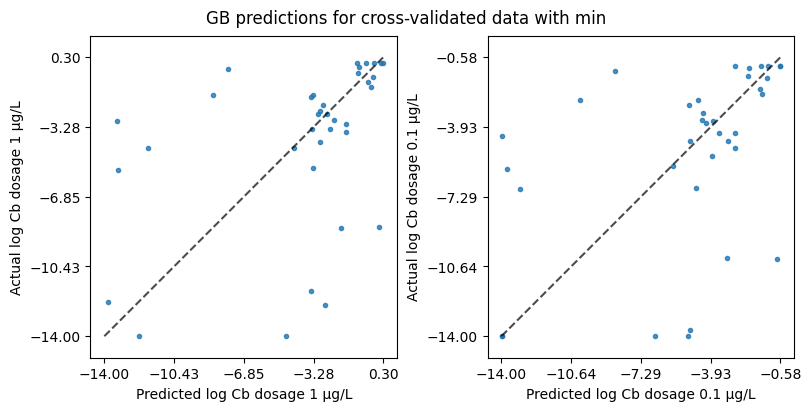

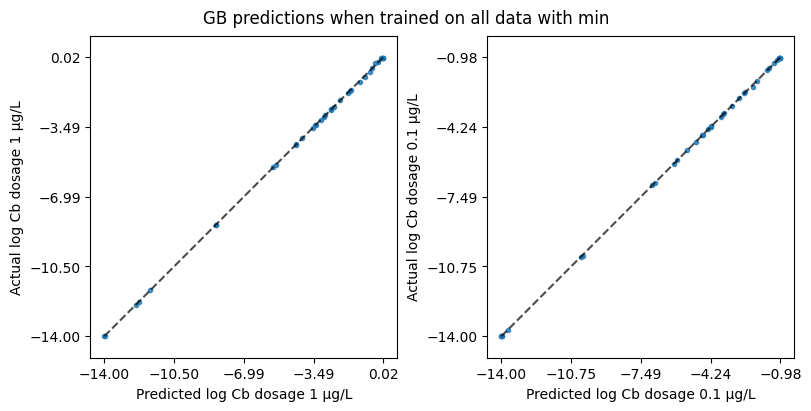

In [9]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import PredictionErrorDisplay

for name, model in (('KRR', KernelRidge), ('GB', GradientBoostingRegressor)):
    for setting, ind in (('normal', X), ('min', X_min)):
        fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout='constrained')
        for tar, ax in zip(['log Cb dosage 1 µg/L', 'log Cb dosage 0.1 µg/L'], axs):
            y_pred = cross_val_predict(model(**best_param_dict[setting][tar][name]), ind, data[tar], cv=LeaveOneOut())
            print(f"R2 for {tar}: {r2_score(data[tar], y_pred)}")
            print(f"RMSE for {tar}: {root_mean_squared_error(data[tar], y_pred)}")
            PredictionErrorDisplay.from_predictions(data[tar], y_pred, kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker': '.'})
            ax.set(xlabel=f'Predicted {tar}', ylabel=f'Actual {tar}')
        fig.suptitle(name + ' predictions for cross-validated data with ' + setting)
        plt.savefig(Path(os.getcwd()) / 'plots' / f'{name}_{setting}_cross-validated_actual_vs_predicted.png', dpi=1500)
        plt.show()

        fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout='constrained')
        for tar, ax in zip(target_cols, axs):
            estimator = model(**best_param_dict[setting][tar][name]).fit(ind, data[tar])
            PredictionErrorDisplay.from_estimator(estimator, ind, data[tar], kind='actual_vs_predicted', ax=ax, scatter_kwargs={'marker': '.'})
            ax.set(xlabel=f'Predicted {tar}', ylabel=f'Actual {tar}')
        fig.suptitle(name + ' predictions when trained on all data with ' + setting)
        plt.savefig(Path(os.getcwd()) / 'plots' / f'{name}_{setting}_all-data_actual_vs_predicted.png', dpi=1500)
        plt.show()

## Evaluation

Results of a global sensitivity analysis after Sobol. The plots show pie-plots of total order indices, one plot per model class. The RF models are also presented as Figure 3 in the main text, and all plots as Figure S7 in the Supplementary Information. Due to the overfitting of GB and KRR the respective GSA carries no reliable information.

Abraham's importances (in %) for log Cb dosage 1 µg/L:
E: 38.51%, S: 6.99%, A: 54.25%, B: 0.2%, V: 0.06%, L: 0.0%
Abraham's importances (in %) for log Cb dosage 0.1 µg/L:
E: 37.2%, S: 7.64%, A: 54.93%, B: 0.13%, V: 0.08%, L: 0.01%


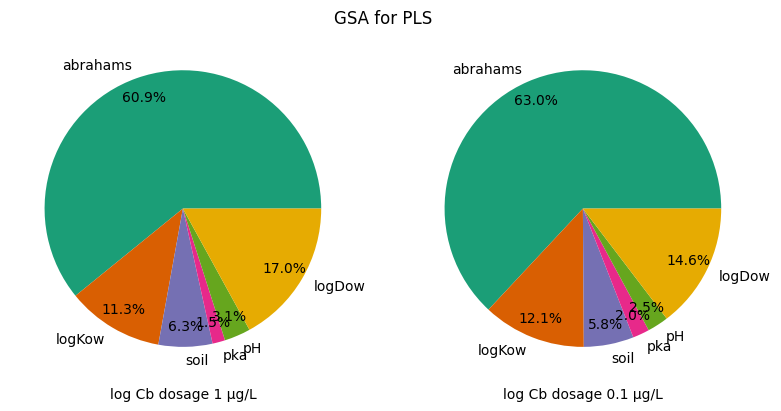

Abraham's importances (in %) for log Cb dosage 1 µg/L:
E: 40.36%, S: 8.08%, A: 49.97%, B: 1.42%, V: 0.1%, L: 0.06%
Abraham's importances (in %) for log Cb dosage 0.1 µg/L:
E: 36.6%, S: 10.16%, A: 51.56%, B: 1.59%, V: 0.04%, L: 0.05%


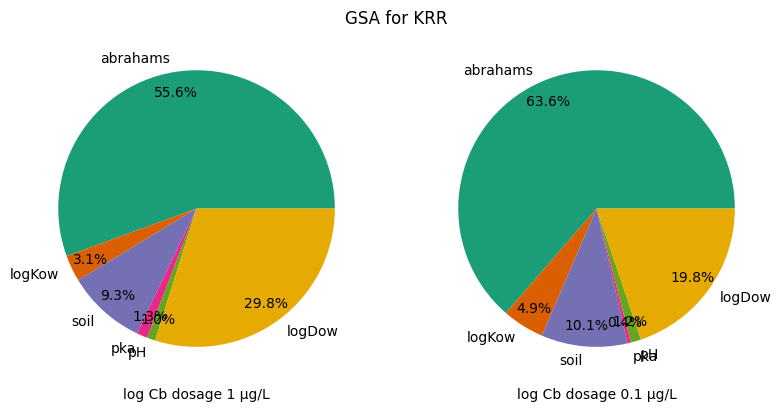

Abraham's importances (in %) for log Cb dosage 1 µg/L:
E: 4.31%, S: 0.07%, A: 89.63%, B: 0.01%, V: 0.29%, L: 5.69%
Abraham's importances (in %) for log Cb dosage 0.1 µg/L:
E: 1.4%, S: 0.03%, A: 96.77%, B: 0.47%, V: 1.29%, L: 0.05%


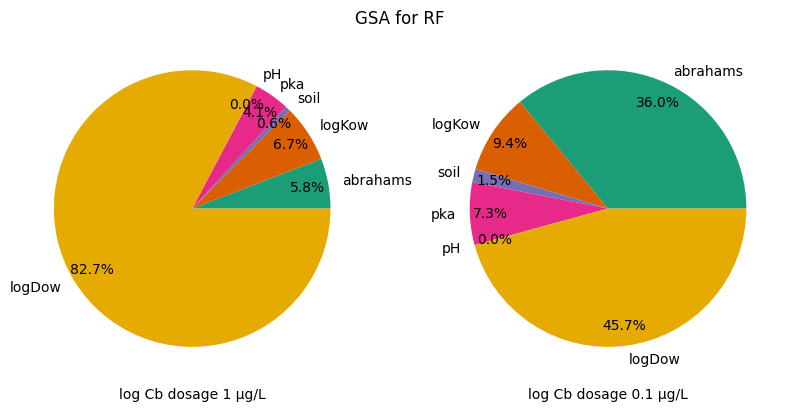

Abraham's importances (in %) for log Cb dosage 1 µg/L:
E: 10.64%, S: 37.03%, A: 2.05%, B: 13.55%, V: 27.71%, L: 9.01%
Abraham's importances (in %) for log Cb dosage 0.1 µg/L:
E: 5.25%, S: 5.38%, A: 1.04%, B: 32.57%, V: 32.89%, L: 22.86%


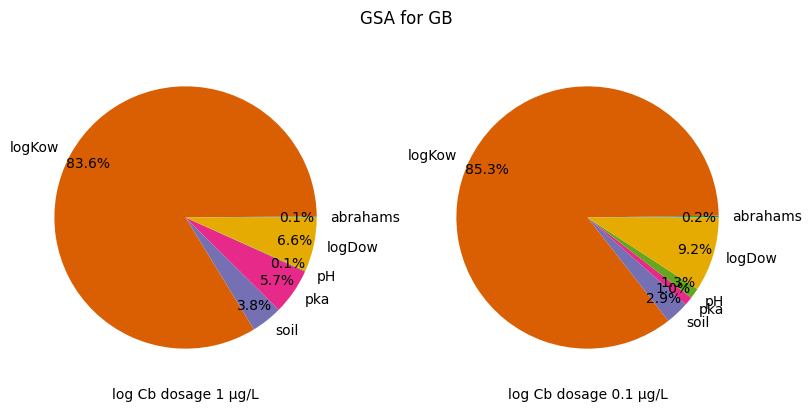

In [8]:
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats
from scipy.stats import sobol_indices

from train_utils import get_model_path

for name, model in (
    ('PLS', PLSRegression()), ('KRR', KernelRidge()),
    ('RF', RandomForestRegressor()), ('GB', GradientBoostingRegressor()),
    ):
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout='constrained')
    for target, ax in zip(target_cols, axs):
        model_dir = Path(os.getcwd()) / 'models'
        model = model.set_params(**best_param_dict['normal'][target][name])
        save_path = get_model_path(
            model, target, model_dir, sobol=True
        )
        # load sobol indices
        if save_path.is_file():
            with open(save_path, 'rb') as fh:
                (indices_first_order, indices_total_order), boot = pickle.load(fh)
        # else calculate them
        else:
            os.makedirs(save_path.parent, exist_ok=True)
            y = data[target]
            clf = estimator=Pipeline([
                    ('scaling', StandardScaler()),
                    ('regressor', model)
                ]).fit(X, y)

            dist = [stats.uniform(X[col].min(), X[col].max() - X[col].min()) for col in X.columns]

            indices = sobol_indices(func=lambda x: clf.predict(x.T), n=2**16, dists=dist)
            boot = indices.bootstrap()
            with open(save_path, 'wb') as fh:
                pickle.dump(((indices.first_order, indices.total_order), boot), fh)
                indices_first_order = indices.first_order
                indices_total_order = indices.total_order
        # pie plot of the sobol indices
        sorted_labels = ['abrahams', X.columns[8], 'soil', X.columns[9]] + list(X.columns[-7:9:-1])
        combined_indices = [indices_total_order[-6:].sum()] + [indices_total_order[8]] \
            + [indices_total_order[:8].sum()]  + [indices_total_order[9]] + list(indices_total_order[-7:9:-1])
        ax.pie(
            combined_indices, autopct='%1.1f%%', labels=sorted_labels,
            colors=plt.cm.Dark2.colors, pctdistance=0.85
        )
        ax.set(xlabel=f'{target}')
        abrahams_proportions = indices_total_order[-6:] / indices_total_order[-6:].sum()
        print(f"Abraham's importances (in %) for {target}:")
        imps = list(zip(X.columns[-6:], map(float, (100 * abrahams_proportions).round(2))))
        print_imps = [f"{x[0]}: {x[1]}%" for x in imps]
        imps_str = ", ".join(print_imps)
        print(imps_str)
    fig.suptitle(f'GSA for {name}')
    save_path = Path(os.getcwd()) / 'plots' / f'{name}_sobol.png'
    plt.savefig(save_path, dpi=1500)
    plt.show()

Looking at the correlations in the data set we can explain some phenomena seen in the sobol plots (also presented in Table S7 in the Supplementary Information).

The Abraham's parameters S, B, V and L correlate strongly, which signifies that we can characterize sorbates (via abrahams parameters) in our data with E, A and one other parameter. This is nicely reflected in the PLS models, with the huge influence of E, S and A (which can be explained by the linearity of PLS, as we do not expect any non-linear interactions between variables).

WHC correlates strongly with CEC $[meq/100g]$ and other soil parameters, which explains that we cannot get more information from that value when including as independent variable.

In [ ]:
print('Correlations for the sorbat features')
display(data.loc[:, sorbat_cols + abrahams_cols].corr().style.background_gradient(cmap='coolwarm'))
print('Correlations for the soil features')
display(data.loc[:, soil_cols + ['pH', 'WHC']].corr().style.background_gradient(cmap='coolwarm'))
print('Correlations for the minimal feature set')
display(data.loc[:, sorbat_cols + ['pH', 'WHC']].corr().style.background_gradient(cmap='coolwarm'))

Correlations for the sorbat features


,logKow,pka,logDow,E,S,A,B,V,L
logKow,1.000000,-0.411954,0.580638,0.746981,0.189502,0.209955,0.169389,0.386140,0.374418
pka,-0.411954,1.000000,-0.872204,0.277711,-0.017783,0.425662,0.112096,-0.052677,0.039167
logDow,0.580638,-0.872204,1.000000,-0.011724,0.174309,-0.337700,0.089890,0.264251,0.184924
E,0.746981,0.277711,-0.011724,1.000000,0.220983,0.411334,0.284196,0.380055,0.445263
S,0.189502,-0.017783,0.174309,0.220983,1.000000,-0.335697,0.921065,0.933510,0.949133
A,0.209955,0.425662,-0.337700,0.411334,-0.335697,1.000000,-0.362985,-0.275307,-0.238025
B,0.169389,0.112096,0.089890,0.284196,0.921065,-0.362985,1.000000,0.965475,0.963888
V,0.386140,-0.052677,0.264251,0.380055,0.933510,-0.275307,0.965475,1.000000,0.989808
L,0.374418,0.039167,0.184924,0.445263,0.949133,-0.238025,0.963888,0.989808,1.000000


Correlations for the soil features


,Corg [% C],CEC [meq/100g],F quartz,F non ex clay,F ex clay,Feldspar,Silicate,BET,pH,WHC
Corg [% C],1.000000,0.676592,-0.263330,0.310176,0.160308,0.066159,-0.596345,0.439998,0.520183,0.420684
CEC [meq/100g],0.676592,1.000000,-0.863974,0.289993,0.651289,-0.254730,-0.468954,0.848232,0.875237,0.924591
F quartz,-0.263330,-0.863974,1.000000,-0.301437,-0.749123,0.456220,0.425764,-0.908475,-0.719725,-0.940501
F non ex clay,0.310176,0.289993,-0.301437,1.000000,-0.352674,-0.643983,-0.314172,0.609904,0.227552,0.060634
F ex clay,0.160308,0.651289,-0.749123,-0.352674,1.000000,-0.064385,-0.413911,0.514045,0.431448,0.872998
Feldspar,0.066159,-0.254730,0.456220,-0.643983,-0.064385,1.000000,0.193470,-0.675059,-0.030099,-0.227318
Silicate,-0.596345,-0.468954,0.425764,-0.314172,-0.413911,0.193470,1.000000,-0.559886,-0.059937,-0.457698
BET,0.439998,0.848232,-0.908475,0.609904,0.514045,-0.675059,-0.559886,1.000000,0.625540,0.803252
pH,0.520183,0.875237,-0.719725,0.227552,0.431448,-0.030099,-0.059937,0.625540,1.000000,0.767237
WHC,0.420684,0.924591,-0.940501,0.060634,0.872998,-0.227318,-0.457698,0.803252,0.767237,1.000000


Correlations for the minimal feature set


,logKow,pka,logDow,pH,WHC
logKow,1.000000,-0.411954,0.580638,0.000000,-0.000000
pka,-0.411954,1.000000,-0.872204,-0.000000,0.000000
logDow,0.580638,-0.872204,1.000000,0.289023,0.218428
pH,0.000000,-0.000000,0.289023,1.000000,0.767237
WHC,-0.000000,0.000000,0.218428,0.767237,1.000000
